### 03. 梯度下降(算法) Gradient Descent 10-15
前面已经知道：

- 模型：$f_{w,b}(x)=wx+b$
- (策略)成本函数：$ J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2 $
- (算法)梯度下降是目标：找到让 $J(w,b)$ 最小的 $w,b$
---
#### 1. 梯度下降

梯度下降的作用：
> 不断调整 $w,b$，让成本函数 $J(w,b)$ 变小。

可以理解成：

- 现在站在山坡上，360度旋转，为了下山，应该朝那个方向迈步
- 找到下坡方向
- 往下坡方向走一步
- 重复很多次
- 最后接近最低点

最低点就是：$J(w,b)$ 最小的位置。

---

#### 2. 实现梯度下降 

梯度下降会不断更新参数：

| 参数 | 更新公式 |
|---|---|
| $w$ | $w = w - \alpha \frac{\partial J(w,b)}{\partial w}$ |
| $b$ | $b = b - \alpha \frac{\partial J(w,b)}{\partial b}$ |

其中：
- = 是给w赋值
- $\alpha$：学习率（learning rate）通常是0-1之间的小正数，控制下坡时步子的大小
- 模型：$ f_{w,b}(x^{(i)})=wx^{(i)}+b $
- 成本函数：$ J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2 $
- $ \frac{\partial J(w,b)}{\partial w}$：告诉 $w$ 应该怎么变，求导后：$\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})*x^{(i)}$
- $ \frac{\partial J(w,b)}{\partial b}$：告诉 $b$ 应该怎么变，求导后：$\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})$
- 
>重点： $w$ 和 $b$ 要同时更新。

---

#### 3. 梯度下降直觉 
> 导数可以理解成：当前点的斜率。

用开口向上的抛物线举例（U）假设b为0

如果某个点在极小值的右侧，则(导数)斜率是正的：w = w-求导后的结果，最终会得到一个更小的w

- 在图上表示参数应该往左走，减小w的值，让 代价cost J(w)变小

如果在极小值的左侧，则(导数)斜率是负的：w = w-求导后的结果，最终会得到一个更大的w

- 在图上表示参数应该往右走，增加w的值，让代价cost J(w)变小

所以梯度下降会根据斜率判断：
> 参数应该往哪个方向调整。
> 
> 核心：斜率决定方向，学习率决定步子大小。

---

#### 4. 学习率

学习率 $\alpha$ 控制每次走多大一步。

如果 $\alpha$ 太小：每一步很小，下降很慢，需要训练很多次

如果 $\alpha$ 太大：每一步太大，可能跨过最低点，使cost 可能越来越大

所以：

> 学习率不能太大，也不能太小。
> 
> 当接近局部最小值时，导数会越来越小，梯度下降会采取更小的步骤(学习率a)，也就是学习率逐渐减小
---

#### 5. 线性回归的梯度下降

当使用线性回归的平方误差成本函数后，成本函数 $J(w,b)$ 不会有多个局部最小值，是一个凸函数。类似于U(从上往下看)
>也就是像一个碗一样，只有一个最低点。

所以线性回归中使用梯度下降时：

- 不用担心卡在很多局部最低点
- 目标就是找到这个碗底
- 碗底对应的 $w,b$ 就是最优参数
>核心： 对线性回归来说，梯度下降最终会朝着全局最低点前进。

---


#### 7. 梯度下降总结

本部分需要记住：

1. 成本函数 $J(w,b)$ 用来衡量模型好不好
2. 梯度下降用来自动调整 $w,b$
3. 目标是让 $J(w,b)$ 越来越小
4. 学习率 $\alpha$ 决定每次走多大一步
5. 线性回归的成本函数像一个碗，最低点就是最优参数

最核心一句话：

> 梯度下降就是不断更新 $w,b$，让成本函数 $J(w,b)$ 一步一步变小。

#### 8. 代码
代码流程如下：

In [1]:
"""
1. 导入成本函数作业需要的工具
2. 准备训练数据
3. 实现成本函数 compute_cost
"""

#1. 导包
import numpy as np
import matplotlib.pyplot as plt
import math, copy #调用数学常用函数，复制工具
from lab_utils_uni import plt_house_x, plt_contour_wgrad, plt_divergence, plt_gradients

# 2. 准备训练数据
x_train = np.array([1.0, 2.0])   
y_train = np.array([300.0, 500.0])  

#3. 实现成本函数 compute_cost
def compute_cost(x, y, w, b):
   
    m = x.shape[0] 
    cost = 0
    
    for i in range(m):
        f_wb = w * x[i] + b
        cost = cost + (f_wb - y[i])**2
    total_cost = 1 / (2 * m) * cost

    return total_cost

- 模型：$ f_{w,b}(x^{(i)})=wx^{(i)}+b $
- 成本函数：$ J(w,b) = \frac{1}{2m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})^2 $
- $ \frac{\partial J(w,b)}{\partial w}$：告诉 $w$ 应该怎么变，求导后：$\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})*x^{(i)}$
- $ \frac{\partial J(w,b)}{\partial b}$：告诉 $b$ 应该怎么变，求导后：$\frac{1}{m}\sum_{i=1}^{m}(f_{w,b}(x^{(i)}) - y^{(i)})$

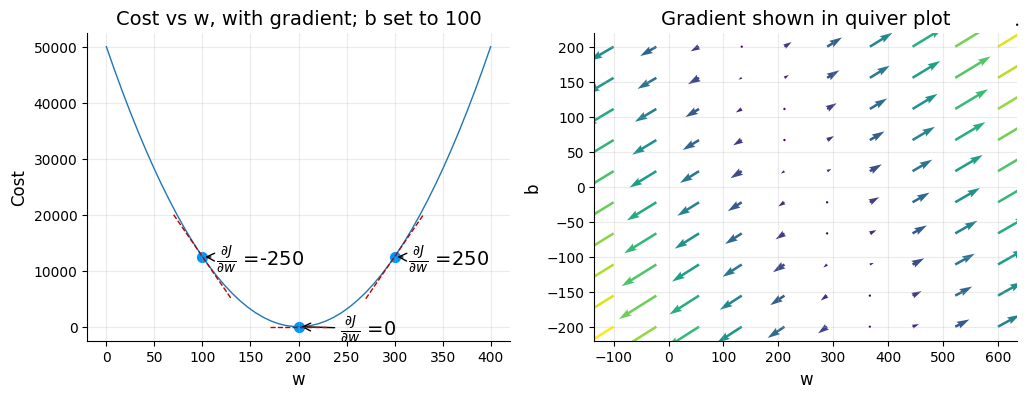

In [ ]:
""" 
4. 梯度计算与可视化
   compute_gradient来算:损失函数J(w,b)对 w 和 b 的梯度（导数，斜率）
    两个梯度公式:
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]

简单说，这段代码就是为后面的梯度下降算法做准备。后面梯度下降会用它不断更新：
w = w - α * dj_dw
b = b - α * dj_db
"""

def compute_gradient(x, y, w, b): 

    m = x.shape[0]  

    # 初始化梯度为 0 
    dj_dw = 0
    dj_db = 0
    
    for i in range(m):  
        f_wb = w * x[i] + b  # 模型预测值
        dj_dw_i = (f_wb - y[i]) * x[i] # 第 i 个样本对 w 的导数
        dj_db_i = f_wb - y[i]          # 第 i 个样本对 b 的导数
        dj_db += dj_db_i     # 累加 b 的梯度
        dj_dw += dj_dw_i     # 累加 w 的梯度

    # 最后求平均（除以 m）
    dj_dw = dj_dw / m 
    dj_db = dj_db / m 
        
    return dj_dw, dj_db

#调用成本函数(compute_cost),梯度计算(compute_gradient)
plt_gradients(x_train,y_train, compute_cost, compute_gradient)
plt.show()

"""
图1:固定 b = 100,只看不同 w 对成本函数 J(w,b) 的影响。Cost 和 w 的关系
图2:每个箭头表示在某个 (w, b) 位置上，成本函数下降或上升的方向趋势。箭头越长，说明当前位置梯度越大，也就是模型参数离最优解越远
    当b=100,w=200时,差不多是一个点。不同 w、b 位置上的梯度方向
"""

In [4]:
"""
5. 实现梯度下降算法 gradient_descent
    作用:动找到比较合适的w和b,让成本函数 J(w,b) 越来越小

    参数:
        x, y: 训练数据
        w_in, b_in: 初始的 w 和 b
        alpha: 学习率，控制每次更新的步长
        num_iters: 迭代次数,也就是调整多少次
        cost_function: 计算成本的函数
        gradient_function: 计算梯度的函数  
"""
def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function): 
  
    J_history = [] # 创建列表，用来保存每一次迭代后的 cost,如果梯度下降正常，J_history 里面的值应该越来越小。
    p_history = [] # 创建列表，用来保存每一次迭代后的 (w,b) 参数
    b = b_in # 设置初始 b
    w = w_in # 设置初始 w
    
    # 开始循环，执行num_iters 次
    for i in range(num_iters):
      
        # 计算当前 w,b 下的梯度
        # dj_dw 表示 J 对 w 的变化方向
        # dj_db 表示 J 对 b 的变化方向
        dj_dw, dj_db = gradient_function(x, y, w , b)     

        # 更新 b,w。根据梯度下降公式
        # b = b - alpha * dj_db 
        # w = w - alpha * dj_dw
        b = b - alpha * dj_db                            
        w = w - alpha * dj_dw                            

        # 保存每一次迭代后的 cost 和 (w,b) 参数
        # i < 100000 是为了防止保存太多数据，导致内存占用太大   
        if i<100000:     
            J_history.append( cost_function(x, y, w , b)) #每次循环都计算一个新的 cost，然后把它追加到 J_history 这个列表的最后
            p_history.append([w,b]) #把当前的 w 和 b 保存起来。


        # 每隔一段时间打印一次训练过程
        # math.ceil(num_iters / 10) 表示大约打印 10 次
        if i% math.ceil(num_iters/10) == 0:
            print(f"Iteration {i}:",      #打印当前迭代次数
                  f"Cost {J_history[-1]:.8f} ", #取最后一个值也就是最新的cost值,越小越好
                  f"dj_dw:{dj_dw: .4f}, dj_db:{dj_db: .4f}  ", #打印梯度
                  f"w: {w:.6f}, b:{b: .6f}") #打印w和b的值
                  # .6f 的意思是：只保留 6 位小数。
 
    return w, b, J_history, p_history 

"""
6,运行梯度下降
    这里设置初始参数、学习率、迭代次数
    然后调用 gradient_descent() 开始训练
"""

# 初始化 w 和 b
w_init = 0
b_init = 0

# 设置迭代次数
# 表示梯度下降要更新参数 10000 次
iterations = 10000

# 设置学习率 alpha
# 1.0e-2 就是 0.01
tmp_alpha = 1.0e-2

w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)
print(f"梯度下降找到的最终参数: w = {w_final:.6f}, b = {b_final:.6f}")


Iteration 0: Cost 79274.81250000  dj_dw:-650.0000, dj_db:-400.0000   w: 6.500000, b: 4.000000
Iteration 1000: Cost 3.41251093  dj_dw:-0.3712, dj_db: 0.6007   w: 194.914824, b: 108.227987
Iteration 2000: Cost 0.79289507  dj_dw:-0.1789, dj_db: 0.2895   w: 197.548811, b: 103.966107
Iteration 3000: Cost 0.18422874  dj_dw:-0.0863, dj_db: 0.1396   w: 198.818462, b: 101.911768
Iteration 4000: Cost 0.04280545  dj_dw:-0.0416, dj_db: 0.0673   w: 199.430468, b: 100.921523
Iteration 5000: Cost 0.00994582  dj_dw:-0.0200, dj_db: 0.0324   w: 199.725470, b: 100.444198
Iteration 6000: Cost 0.00231091  dj_dw:-0.0097, dj_db: 0.0156   w: 199.867669, b: 100.214115
Iteration 7000: Cost 0.00053694  dj_dw:-0.0047, dj_db: 0.0075   w: 199.936213, b: 100.103209
Iteration 8000: Cost 0.00012476  dj_dw:-0.0022, dj_db: 0.0036   w: 199.969253, b: 100.049750
Iteration 9000: Cost 0.00002899  dj_dw:-0.0011, dj_db: 0.0018   w: 199.985179, b: 100.023981
梯度下降找到的最终参数: w = 199.992851, b = 100.011568


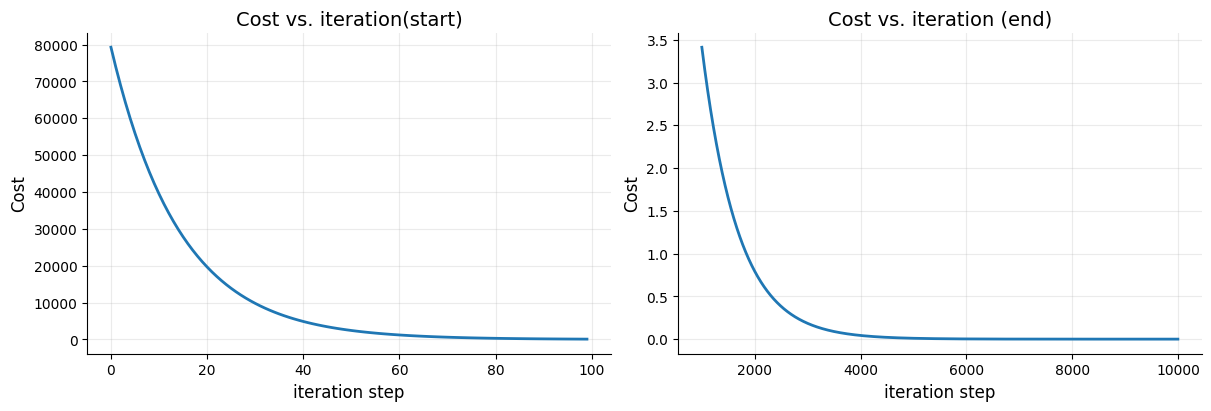

1000 平方英尺房子的预测价格：300.0 千美元
1200 平方英尺房子的预测价格：340.0 千美元


In [ ]:
"""
7,观察 cost 下降过程，并使用训练好的模型进行预测
    第一部分：
        画出 cost 随迭代次数的变化

    第二部分：
        使用梯度下降得到的 w_final 和 b_final
        预测不同面积房子的价格
"""

# 创建一个画布，并在同一行创建两个子图：1, 2 表示：1 行 2 列，constrained_layout=True 表示自动调整图像布局，避免标题和坐标轴挤在一起，figsize=(12,4) 表示图像大小
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))

# 左图：画前 100 次迭代的 cost，作用：观察一开始 cost 是否快速下降
ax1.plot(J_hist[:100]) 

# 右图：画第 1000 次迭代之后的 cost ，作用：观察 cost 是否继续下降，或者已经趋于平稳
"""
ax2.plot(横坐标, 纵坐标)
横坐标:如果总共训练10000次,J_hist[1000:]里面有 9000 个值。len(J_hist[1000:])会生成9000
      np.arange(9000)会生成[0, 1, 2, 3, ..., 8999]
纵坐标:J_hist[1000:]是，从第 1000 个 cost 开始，一直取到最后
"""
ax2.plot(1000 + np.arange(len(J_hist[1000:])), J_hist[1000:]) 
                                                             
ax1.set_title("Cost vs. iteration(start)");  ax2.set_title("Cost vs. iteration (end)") # 设置左图和右图标题
ax1.set_ylabel('Cost')            ;  ax2.set_ylabel('Cost')  # 设置左图和右图的 y 轴名称
ax1.set_xlabel('iteration step')  ;  ax2.set_xlabel('iteration step')  # 设置左图和右图的 x 轴名称
plt.show()


# 使用训练好的 w_final 和 b_final 预测 1000 平方英尺房子的价格
# 预测公式：                 f_wb = w_final * x + b_final
print(f"1000 平方英尺房子的预测价格：{w_final * 1.0 + b_final:.1f} 千美元")
print(f"1200 平方英尺房子的预测价格：{w_final * 1.2 + b_final:.1f} 千美元")

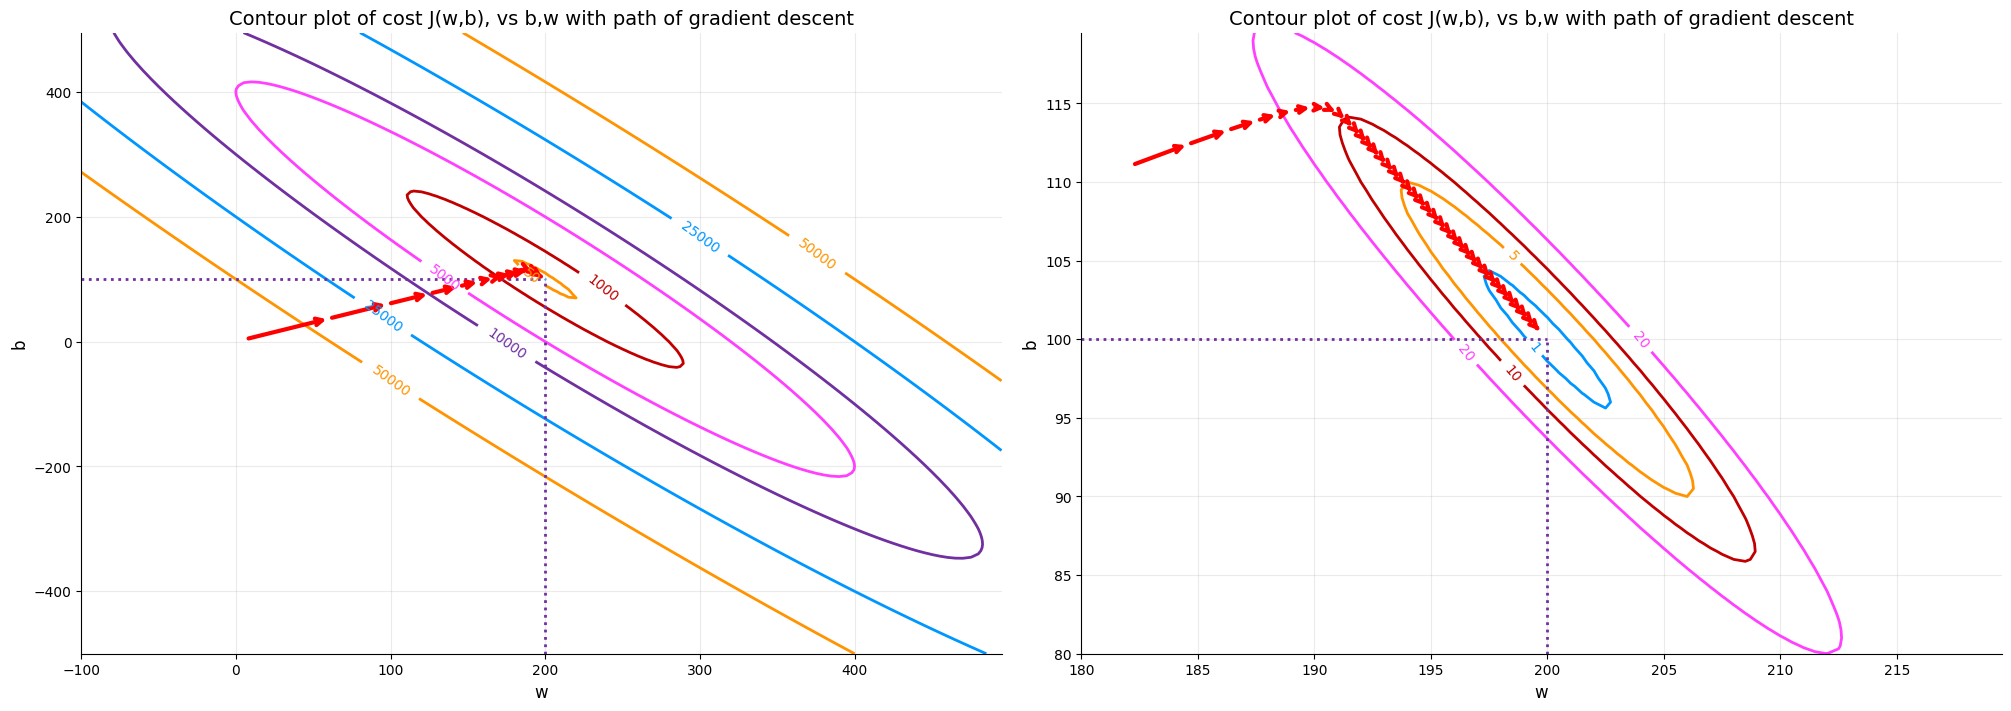

In [6]:
"""
8,可视化梯度下降路径
    这一部分使用课程提供的 plt_contour_wgrad 函数
    左图：
        观察梯度下降的整体路径
        看 w,b 是如何从初始位置走向最低点附近的
    右图：
        放大最低点附近
        更清楚地观察最后几步是否接近最优解
    核心：
        p_hist 保存了梯度下降过程中每一步的 w,b
        plt_contour_wgrad 会把这些 w,b 画在成本函数等高线图上
        如果路径逐渐靠近中心，说明梯度下降在正常工作
"""

# 创建一个画布，并在同一行创建两个子图
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(20, 7))

# 左图：整体观察梯度下降路径
plt.sca(ax1)
plt_contour_wgrad(x_train, y_train, p_hist, ax1)

# 右图：放大观察最低点附近
# 这里额外设置 w_range 和 b_range
# 目的是只观察最优解附近的小范围
plt.sca(ax2)
plt_contour_wgrad(
    x_train,
    y_train,
    p_hist,
    ax2,
    w_range=[180, 220, 0.5],      # w 的显示范围：180 到 220，每隔 0.5 取一个点
    b_range=[80, 120, 0.5],       # b 的显示范围：80 到 120，每隔 0.5 取一个点
    contours=[1, 5, 10, 20],      # 只画 cost = 1,5,10,20 的等高线
    resolution=0.5                # 图像计算精度，数值越小图越细
)

plt.show()

Iteration 0: Cost 257800.00000000  dj_dw:-650.0000, dj_db:-400.0000   w: 520.000000, b: 320.000000
Iteration 1: Cost 781960.00000000  dj_dw: 1130.0000, dj_db: 700.0000   w: -384.000000, b:-240.000000
Iteration 2: Cost 2371904.32000000  dj_dw:-1970.0000, dj_db:-1216.0000   w: 1192.000000, b: 732.800000
Iteration 3: Cost 7194705.31840000  dj_dw: 3429.2000, dj_db: 2120.8000   w: -1551.360000, b:-963.840000
Iteration 4: Cost 21823770.98905602  dj_dw:-5974.1600, dj_db:-3690.8800   w: 3227.968000, b: 1988.864000
Iteration 5: Cost 66198302.85273096  dj_dw: 10403.2160, dj_db: 6430.8160   w: -5094.604800, b:-3155.788800
Iteration 6: Cost 200800132.73054025  dj_dw:-18120.1952, dj_db:-11197.6960   w: 9401.551360, b: 5802.368000
Iteration 7: Cost 609089564.95101249  dj_dw: 31557.4304, dj_db: 19504.6950   w: -15844.392960, b:-9801.388032
Iteration 8: Cost 1847559057.61590838  dj_dw:-54963.0644, dj_db:-33967.9775   w: 28126.058598, b: 17372.993946
Iteration 9: Cost 5604224211.96211815  dj_dw: 95724.

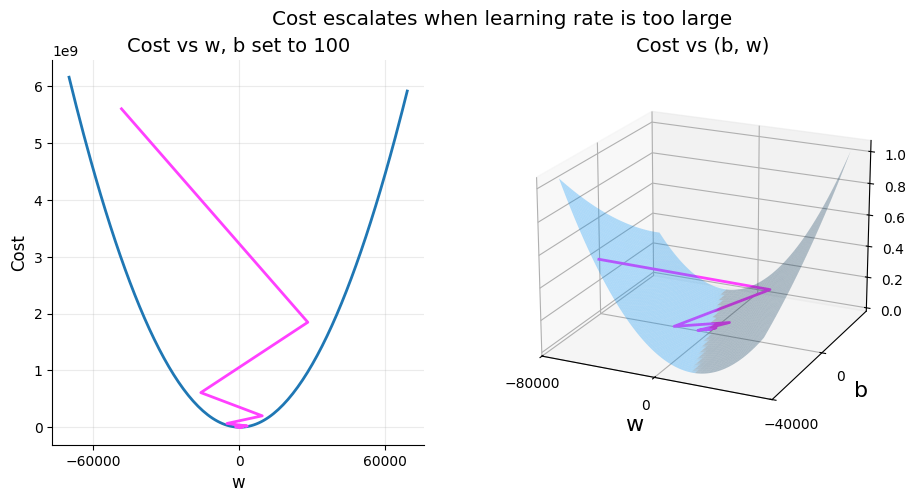

In [ ]:
"""
8,演示学习率太大时的发散情况
    这一部分不是为了训练出好模型
    作用：
        故意把学习率 alpha 设置得很大
        观察梯度下降为什么可能失败
    核心：
        如果 alpha 太大
        参数 w,b 每次更新的步子太大
        可能会跨过最低点
        导致 cost 越来越大
"""
w_init = 0
b_init = 0

# 设置迭代次数
# 这里只训练 10 次，因为 alpha 太大，很快就能看到发散现象
iterations = 10

# 设置一个很大的学习率
# 8.0e-1 就是 0.8
# 对这个例子来说，0.8 太大了，容易导致梯度下降发散
tmp_alpha = 8.0e-1

# 运行梯度下降
# 这里使用较大的 alpha，观察 cost 是否会越来越大
w_final, b_final, J_hist, p_hist = gradient_descent(x_train ,y_train, w_init, b_init, tmp_alpha, 
                                                    iterations, compute_cost, compute_gradient)

# 使用课程提供的函数，画出发散过程
# p_hist 保存了每一步的 w,b
# J_hist 保存了每一步的 cost
# 这个图可以帮助观察为什么学习率太大会导致失败
plt_divergence(p_hist, J_hist,x_train, y_train)
plt.show()